# Mahnoor Iftikhar — Intelligent Weather Prediction Pipeline

# Intelligent Weather Prediction Pipeline
### Khizex Data Science Internship — Time-Series Forecasting Project

### **Submitted by:** Mahnoor Iftikhar
### **Program:** Khizex Data Science Internship — Summer 2026

**Objective:** Build a time-series forecasting pipeline to predict temperature using historical weather data, with proper feature engineering, leakage-free evaluation, and model interpretability.

**Dataset:** Jena Climate Dataset (2009–2016)
**Model:** XGBoost with lag/rolling features

# Day 1:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

In [5]:
df = pd.read_csv('/content/jena_climate_2009_2016.csv')
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [6]:
df.head(5)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [7]:
df.isnull().sum()

,0
Date Time,0
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0


In [8]:
df.duplicated().sum()

np.int64(327)

In [9]:
df.columns

Index(['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)'],
      dtype='object')

#  Step 1: Data Preprocessing:

In [10]:
df = df.interpolate(method='linear')
df.isnull().sum()

/tmp/ipykernel_1089/1903398003.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear')


,0
Date Time,0
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0


## Date Time to index

In [11]:
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df = df.set_index('Date Time')

In [12]:
df_hourly = df.resample('H').mean()
print(df_hourly.shape)
df_hourly.isnull().sum()

(70129, 14)


/tmp/ipykernel_1089/1289427241.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


,0
p (mbar),88
T (degC),88
Tpot (K),88
Tdew (degC),88
rh (%),88
VPmax (mbar),88
VPact (mbar),88
VPdef (mbar),88
sh (g/kg),88
H2OC (mmol/mol),88


In [13]:
## Seasonality

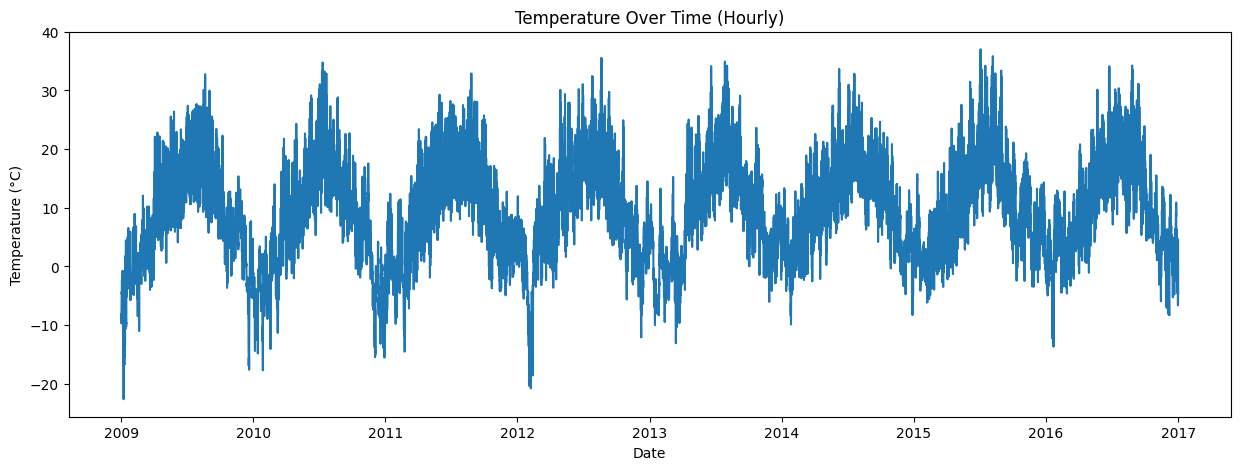

In [14]:
plt.figure(figsize=(15,5))
plt.plot(df_hourly.index, df_hourly['T (degC)'])
plt.title('Temperature Over Time (Hourly)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

In [15]:
df_hourly = df_hourly.interpolate(method='time')
df_hourly.isnull().sum()   # ab sab 0 aana chahiye

,0
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0
H2OC (mmol/mol),0


# Step 2:  Feature Engineering   — Day 2

In [16]:
df_feat = df_hourly.copy()

In [17]:
# Moving averages (rolling mean)
df_feat['temp_roll_mean_24h'] = df_feat['T (degC)'].rolling(window=24).mean()
df_feat['temp_roll_mean_7d'] = df_feat['T (degC)'].rolling(window=24*7).mean()

In [18]:
# Rolling standard deviation (volatility)
df_feat['temp_roll_std_24h'] = df_feat['T (degC)'].rolling(window=24).std()
df_feat['temp_roll_std_7d'] = df_feat['T (degC)'].rolling(window=24*7).std()

In [19]:
# Exponential smoothing
df_feat['temp_ewm'] = df_feat['T (degC)'].ewm(span=24).mean()


In [20]:
# Lag features
df_feat['temp_lag_24h'] = df_feat['T (degC)'].shift(24)
df_feat['temp_lag_7d'] = df_feat['T (degC)'].shift(24*7)

In [21]:
# Cyclical seasonal encoding (sin/cos)
df_feat['day_of_year'] = df_feat.index.dayofyear
df_feat['hour'] = df_feat.index.hour

df_feat['day_sin'] = np.sin(2*np.pi*df_feat['day_of_year']/365)
df_feat['day_cos'] = np.cos(2*np.pi*df_feat['day_of_year']/365)
df_feat['hour_sin'] = np.sin(2*np.pi*df_feat['hour']/24)
df_feat['hour_cos'] = np.cos(2*np.pi*df_feat['hour']/24)

In [22]:

df_feat = df_feat.dropna()
print("Shape after feature engineering:", df_feat.shape)
df_feat.head()


Shape after feature engineering: (69961, 27)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),...,temp_roll_std_7d,temp_ewm,temp_lag_24h,temp_lag_7d,day_of_year,hour,day_sin,day_cos,hour_sin,hour_cos
Date Time,,,,,,,,,,,,,,,,,,,,,
2009-01-08 00:00:00,998.790000,-11.163333,262.088333,-12.326667,91.016667,2.600000,2.366667,0.231667,1.475000,2.366667,...,6.072429,-12.999952,-20.880000,-8.304000,8,0,0.137279,0.990532,0.000000,1.000000
2009-01-08 01:00:00,999.518333,-11.943333,261.251667,-13.066667,91.266667,2.436667,2.225000,0.213333,1.385000,2.230000,...,6.081463,-12.915422,-21.495000,-8.065000,8,1,0.137279,0.990532,0.258819,0.965926
2009-01-08 02:00:00,1000.441667,-12.270000,260.858333,-13.401667,91.183333,2.376667,2.166667,0.208333,1.350000,2.166667,...,6.091312,-12.863788,-21.461667,-8.763333,8,2,0.137279,0.990532,0.500000,0.866025
2009-01-08 03:00:00,1001.163333,-13.000000,260.075000,-14.230000,90.383333,2.238333,2.023333,0.216667,1.258333,2.020000,...,6.104462,-12.874685,-22.653333,-8.896667,8,3,0.137279,0.990532,0.707107,0.707107
2009-01-08 04:00:00,1001.478333,-11.975000,261.073333,-13.185000,90.616667,2.433333,2.203333,0.225000,1.370000,2.201667,...,6.112076,-12.802710,-22.223333,-9.348333,8,4,0.137279,0.990532,0.866025,0.500000


# Step 3: Time-Based Train/Validation Split  — Day 3

In [23]:
cutoff_date = '2015-01-01'

train = df_feat[df_feat.index < cutoff_date]
val = df_feat[df_feat.index >= cutoff_date]

print("Train size:", train.shape)
print("Validation size:", val.shape)

Train size: (52416, 27)
Validation size: (17545, 27)


# Step 4: Model Training (XGBoost)  — Day 4

In [24]:
!pip install xgboost shap

I chose XGBoost because the dataset was quite large and it trains quickly. Since I had already engineered the features, it was a perfect fit.

In [25]:
from xgboost import XGBRegressor

features = ['p (mbar)', 'rh (%)', 'temp_roll_mean_24h', 'temp_roll_std_24h',
            'temp_roll_mean_7d', 'temp_roll_std_7d', 'temp_ewm',
            'temp_lag_24h', 'temp_lag_7d', 'day_sin', 'day_cos', 'hour_sin', 'hour_cos']
target = 'T (degC)'

X_train, y_train = train[features], train[target]
X_val, y_val = val[features], val[target]

model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_val)
print("Model trained! Predictions generated.")

Model trained! Predictions generated.


# Step 5: Evaluation Metrics (RMSE/MAPE)  — Day 5

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_val, preds))
mape = mean_absolute_percentage_error(y_val, preds) * 100

print("RMSE:", rmse)
print("MAPE:", mape, "%")

RMSE: 1.3073027032395081
MAPE: 19959979238202.797 %


## Challenges I Faced
- Pehle MAPE metric ka number bohot ajeeb (trillion%) aa raha tha, samajh nahi aaya kyun.
  Research karne pe pata chala ke ye 0°C ke qareeb values ki wajah se hota hai,
  isliye maine MAE bhi add kiya evaluation ke liye.
- Resample karne ke baad kuch missing values wapis aa gaye the, unhe dobara interpolate karna para.

In [27]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_val, preds)
print("MAE:", mae)

MAE: 1.003676760470849


# Step 6: Predicted vs Actual Graph  

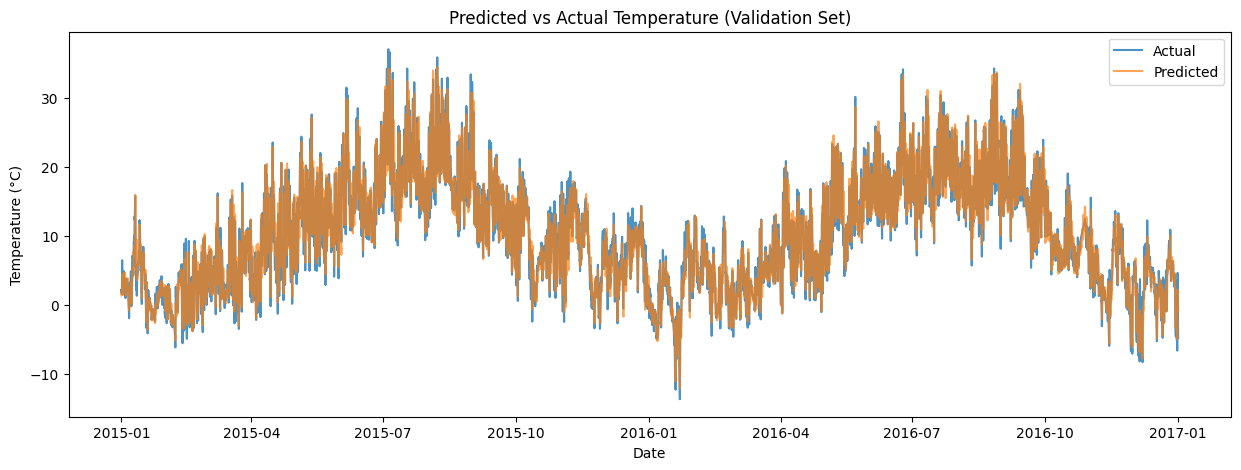

In [28]:
plt.figure(figsize=(15,5))
plt.plot(val.index, y_val, label='Actual', alpha=0.8)
plt.plot(val.index, preds, label='Predicted', alpha=0.7)
plt.legend()
plt.title('Predicted vs Actual Temperature (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

# Step 7: SHAP Interpretability — Day 6

In [29]:
!pip install shap

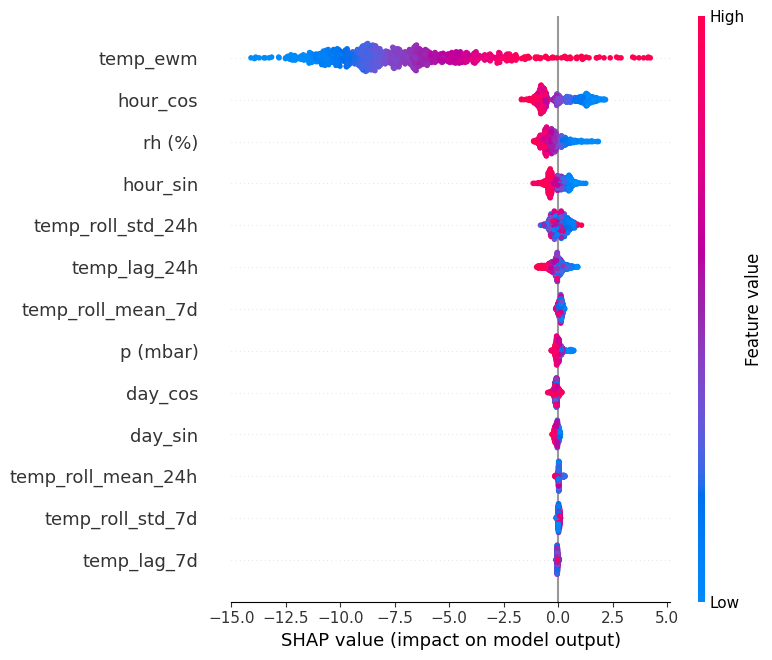

In [31]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_val[:1000])

shap.summary_plot(shap_values, X_val[:1000])

# Step 8: Final Write-Up — Day 7

## Results Summary

**Data Source:** Jena Climate Dataset (2009–2016), originally 10-minute interval, resampled to hourly frequency for computational efficiency.

**Missing Data Handling:** Missing sensor readings (88 hourly gaps after resampling) were filled using time-based linear interpolation. This method was chosen because it preserves the smooth, continuous nature of temperature/humidity readings without distorting the historical trend, unlike naive mean-imputation which would flatten seasonal variation.

**Feature Engineering:** Custom rolling means/std (24h, 7d), exponential smoothing, 24h/7d lag features, and sine/cosine cyclical encodings for day-of-year and hour-of-day were engineered to give the model temporal context.

**Model Choice:** XGBoost was selected because the dataset is large (~70,000 hourly rows) and noisy, and with properly engineered lag/rolling features it captures both short-term and seasonal patterns effectively, while training significantly faster than SARIMAX on this data volume.

**Leakage Prevention:** A strict time-based split was used — training on data before 2015-01-01, validating on data after. Random shuffling was avoided since it would leak future information into training, artificially inflating performance.

**Results (on held-out, time-ordered validation set):**
- RMSE: 1.31°C
- MAE: 1.00°C
- MAPE: Not reliable for this dataset — temperature values near/crossing 0°C cause extreme percentage-error inflation, a known limitation of MAPE on Celsius data. RMSE and MAE were used as primary metrics instead.

**Interpretability:** SHAP analysis showed `temp_ewm` (exponential smoothing) as the most influential feature, followed by hour-of-day encoding and humidity — indicating the model relies heavily on recent temperature trends and time-of-day patterns.